# Buzzhive Data Exploration

This notebook explores the beehive audio dataset to understand:
1. Dataset structure and metadata
2. Label distributions (queen status, etc.)
3. Audio file characteristics
4. Environmental sensor correlations
5. Spectrogram visualization for different hive states


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Paths
DATA_DIR = Path('../archive')
AUDIO_DIR = DATA_DIR / 'sound_files' / 'sound_files'
CSV_PATH = DATA_DIR / 'all_data_updated.csv'

# Create outputs directory
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Audio directory: {AUDIO_DIR.resolve()}")
print(f"CSV path: {CSV_PATH.resolve()}")


Data directory: /Users/mbron/Documents/buzzhive/research/archive
Audio directory: /Users/mbron/Documents/buzzhive/research/archive/sound_files/sound_files
CSV path: /Users/mbron/Documents/buzzhive/research/archive/all_data_updated.csv


## 1. Load and Explore Metadata


In [2]:
# Load the CSV data
df = pd.read_csv(CSV_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)


Dataset shape: (1275, 23)

Columns: ['device', 'hive number', 'date', 'hive temp', 'hive humidity', 'hive pressure', 'weather temp', 'weather humidity', 'weather pressure', 'wind speed', 'gust speed', 'weatherID', 'cloud coverage', 'rain', 'lat', 'long', 'file name', 'queen presence', 'queen acceptance', 'frames', 'target', 'time', 'queen status']

Data types:
device                int64
hive number           int64
date                 object
hive temp           float64
hive humidity       float64
hive pressure       float64
weather temp        float64
weather humidity      int64
weather pressure      int64
wind speed          float64
gust speed          float64
weatherID             int64
cloud coverage        int64
rain                  int64
lat                 float64
long                float64
file name            object
queen presence        int64
queen acceptance      int64
frames                int64
target                int64
time                float64
queen status         

In [3]:
# Display first few rows
df.head(10)


,device,hive number,date,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,wind speed,...,rain,lat,long,file name,queen presence,queen acceptance,frames,target,time,queen status
0,1,5,2022-06-08 14:52:28,36.42,30.29,1007.45,26.68,52,1013,8.75,...,0,37.29,-121.95,2022-06-08--14-52-28_1.raw,1,2,8,0,0.583,0
1,1,5,2022-06-08 15:51:41,33.56,33.98,1006.93,25.99,53,1012,10.29,...,0,37.29,-121.95,2022-06-08--15-51-41_1.raw,1,2,8,0,0.625,0
2,1,5,2022-06-08 17:21:53,29.01,42.73,1006.68,24.49,56,1012,8.75,...,0,37.29,-121.95,2022-06-08--17-21-53_1.raw,0,0,8,1,0.708,1
3,1,5,2022-06-08 18:20:59,30.51,36.74,1006.68,22.97,59,1012,8.23,...,0,37.29,-121.95,2022-06-08--18-20-59_1.raw,0,0,8,1,0.750,1
4,1,5,2022-06-08 19:20:04,30.32,35.55,1006.58,21.52,61,1012,7.20,...,0,37.29,-121.95,2022-06-08--19-20-04_1.raw,0,0,8,1,0.792,1
5,1,5,2022-06-08 20:19:13,29.29,36.34,1006.62,19.44,64,1013,6.69,...,0,37.29,-121.95,2022-06-08--20-19-13_1.raw,0,0,8,1,0.833,1
6,1,5,2022-06-08 21:18:22,25.02,45.67,1007.11,17.02,73,1013,4.12,...,0,37.29,-121.95,2022-06-08--21-18-22_1.raw,0,0,8,1,0.875,1
7,1,5,2022-06-08 22:17:32,23.89,46.37,1007.54,15.93,78,1013,4.12,...,0,37.29,-121.95,2022-06-08--22-17-32_1.raw,0,0,8,1,0.917,1
8,1,5,2022-06-08 23:16:44,22.86,48.23,1007.45,15.33,79,1013,4.63,...,0,37.29,-121.95,2022-06-08--23-16-44_1.raw,0,0,8,1,0.958,1
9,1,5,2022-06-09 0:15:56,22.51,49.07,1007.58,14.58,82,1013,5.14,...,0,37.29,-121.95,2022-06-09--00-15-56_1.raw,0,0,8,1,0.000,1


In [4]:
# Basic statistics
df.describe()


,device,hive number,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,wind speed,gust speed,...,cloud coverage,rain,lat,long,queen presence,queen acceptance,frames,target,time,queen status
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1271.000000,1275.000000,1275.000000,1271.000000,281.000000,...,1275.000000,1275.0,1.271000e+03,1271.00,1275.000000,1275.000000,1275.00000,1275.000000,1275.000000,1275.000000
mean,1.554510,2.709020,29.009475,44.663890,1009.179169,20.326845,63.501176,1011.370196,3.805452,4.511317,...,27.868235,0.0,3.729000e+01,-121.95,0.876078,1.549020,9.10902,3.396863,0.482972,2.127843
std,0.497215,1.488587,8.172418,18.359731,2.406004,5.587868,16.207222,56.807873,2.311196,3.931787,...,33.641333,0.0,7.108224e-15,0.00,0.329621,0.704151,0.99443,1.586142,0.287396,1.096649
min,1.000000,1.000000,15.500000,7.230000,1003.540000,10.750000,0.000000,0.000000,0.000000,0.450000,...,0.000000,0.0,3.729000e+01,-121.95,0.000000,0.000000,8.00000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,22.455000,32.245000,1007.375000,15.480000,51.000000,1013.000000,2.060000,1.340000,...,0.000000,0.0,3.729000e+01,-121.95,1.000000,1.000000,8.00000,3.000000,0.250000,1.000000
50%,2.000000,3.000000,27.910000,42.180000,1009.170000,19.280000,66.000000,1014.000000,3.600000,2.680000,...,20.000000,0.0,3.729000e+01,-121.95,1.000000,2.000000,10.00000,3.000000,0.500000,3.000000
75%,2.000000,4.000000,33.075000,54.945000,1010.705000,24.850000,78.000000,1016.000000,5.660000,7.600000,...,40.000000,0.0,3.729000e+01,-121.95,1.000000,2.000000,10.00000,5.000000,0.750000,3.000000
max,2.000000,5.000000,55.620000,93.470000,1015.970000,35.430000,88.000000,1021.000000,10.800000,15.430000,...,100.000000,0.0,3.729000e+01,-121.95,1.000000,2.000000,10.00000,5.000000,0.958000,3.000000


In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing values:")
print(missing_df[missing_df['Missing Count'] > 0])


Missing values:
              Missing Count  Missing %
weather temp              4   0.313725
wind speed                4   0.313725
gust speed              994  77.960784
lat                       4   0.313725
long                      4   0.313725


## 2. Label Analysis


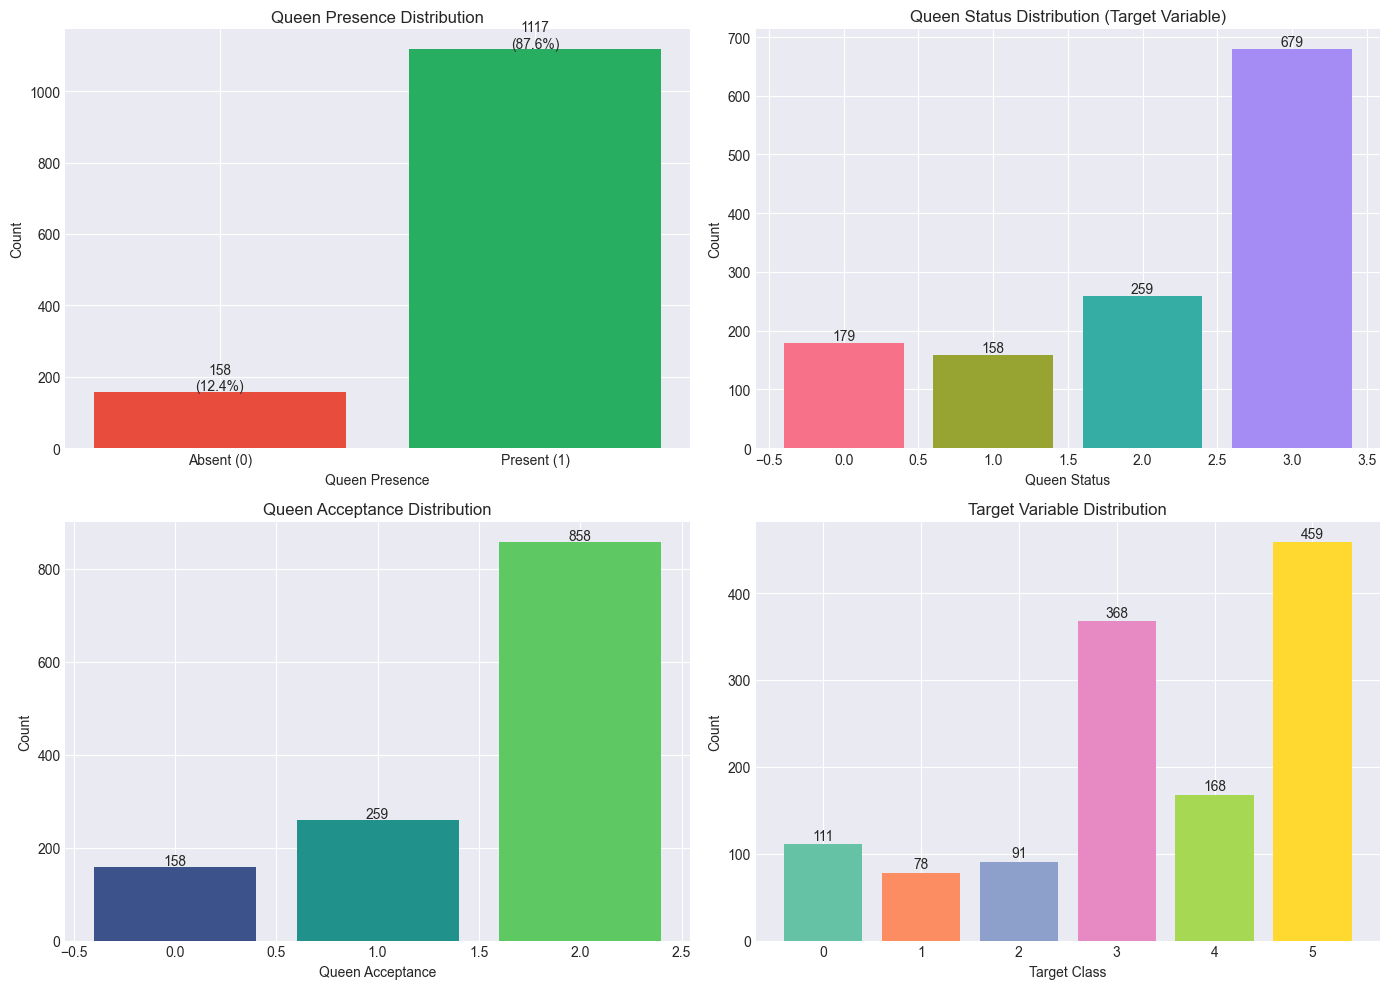


Label value counts:

Queen presence: {0: np.int64(158), 1: np.int64(1117)}
Queen status: {0: np.int64(179), 1: np.int64(158), 2: np.int64(259), 3: np.int64(679)}
Queen acceptance: {0: np.int64(158), 1: np.int64(259), 2: np.int64(858)}
Target: {0: np.int64(111), 1: np.int64(78), 2: np.int64(91), 3: np.int64(368), 4: np.int64(168), 5: np.int64(459)}


In [6]:
# Queen-related label distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Queen presence (binary)
ax1 = axes[0, 0]
queen_presence_counts = df['queen presence'].value_counts().sort_index()
colors = ['#e74c3c', '#27ae60']  # Red for absent, green for present
bars = ax1.bar(queen_presence_counts.index, queen_presence_counts.values, color=colors)
ax1.set_xlabel('Queen Presence')
ax1.set_ylabel('Count')
ax1.set_title('Queen Presence Distribution')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Absent (0)', 'Present (1)'])
for bar, count in zip(bars, queen_presence_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Queen status (multiclass)
ax2 = axes[0, 1]
queen_status_counts = df['queen status'].value_counts().sort_index()
bars = ax2.bar(queen_status_counts.index, queen_status_counts.values, color=sns.color_palette('husl', len(queen_status_counts)))
ax2.set_xlabel('Queen Status')
ax2.set_ylabel('Count')
ax2.set_title('Queen Status Distribution (Target Variable)')
for bar, (status, count) in zip(bars, queen_status_counts.items()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count}', ha='center', fontsize=10)

# Queen acceptance
ax3 = axes[1, 0]
queen_acceptance_counts = df['queen acceptance'].value_counts().sort_index()
bars = ax3.bar(queen_acceptance_counts.index, queen_acceptance_counts.values, 
               color=sns.color_palette('viridis', len(queen_acceptance_counts)))
ax3.set_xlabel('Queen Acceptance')
ax3.set_ylabel('Count')
ax3.set_title('Queen Acceptance Distribution')
for bar, count in zip(bars, queen_acceptance_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count}', ha='center', fontsize=10)

# Target variable
ax4 = axes[1, 1]
target_counts = df['target'].value_counts().sort_index()
bars = ax4.bar(target_counts.index, target_counts.values, 
               color=sns.color_palette('Set2', len(target_counts)))
ax4.set_xlabel('Target Class')
ax4.set_ylabel('Count')
ax4.set_title('Target Variable Distribution')
for bar, count in zip(bars, target_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLabel value counts:")
print(f"\nQueen presence: {dict(queen_presence_counts)}")
print(f"Queen status: {dict(queen_status_counts)}")
print(f"Queen acceptance: {dict(queen_acceptance_counts)}")
print(f"Target: {dict(target_counts)}")


In [7]:
# Analyze relationship between labels
print("Cross-tabulation: Queen Presence vs Queen Status")
print(pd.crosstab(df['queen presence'], df['queen status'], margins=True))

print("\nCross-tabulation: Queen Status vs Target")
print(pd.crosstab(df['queen status'], df['target'], margins=True))


Cross-tabulation: Queen Presence vs Queen Status
queen status      0    1    2    3   All
queen presence                          
0                 0  158    0    0   158
1               179    0  259  679  1117
All             179  158  259  679  1275

Cross-tabulation: Queen Status vs Target
target          0   1   2    3    4    5   All
queen status                                  
0              31   0   0    0    0  148   179
1              80  78   0    0    0    0   158
2               0   0  91    0  168    0   259
3               0   0   0  368    0  311   679
All           111  78  91  368  168  459  1275


In [8]:
# Create a class mapping for our model
# Based on the data exploration:
# queen_status: 0=Queenright(normal), 1=Queenless, 2=Newly Introduced, 3=Accepted

CLASS_MAPPING = {
    0: 'Queenright (Normal)',
    1: 'Queenless',
    2: 'Queen Newly Introduced',
    3: 'Queen Accepted'
}

df['class_name'] = df['queen status'].map(CLASS_MAPPING)
print("Class distribution for modeling:")
print(df['class_name'].value_counts())


Class distribution for modeling:
class_name
Queen Accepted            679
Queen Newly Introduced    259
Queenright (Normal)       179
Queenless                 158
Name: count, dtype: int64


## 3. Audio File Analysis


In [9]:
# List audio files
audio_files = list(AUDIO_DIR.glob('*.wav'))
print(f"Total audio files found: {len(audio_files)}")

# Show sample filenames
print("\nSample filenames:")
for f in sorted(audio_files)[:10]:
    print(f"  {f.name}")


Total audio files found: 7100

Sample filenames:
  2022-06-05--17-41-01_2__segment0.wav
  2022-06-05--17-41-01_2__segment1.wav
  2022-06-05--17-41-01_2__segment2.wav
  2022-06-05--17-41-01_2__segment3.wav
  2022-06-05--17-41-01_2__segment4.wav
  2022-06-05--17-41-01_2__segment5.wav
  2022-06-05--18-40-08_2__segment0.wav
  2022-06-05--18-40-08_2__segment1.wav
  2022-06-05--18-40-08_2__segment2.wav
  2022-06-05--18-40-08_2__segment3.wav


In [10]:
# Analyze file naming pattern
# Files are named: {date}--{time}_{device}__segment{N}.wav
# The CSV references: {date}--{time}_{device}.raw

def get_base_filename(wav_filename):
    """Extract base filename (without segment) from WAV file."""
    name = wav_filename.replace('.wav', '')
    # Remove segment suffix
    if '__segment' in name:
        name = name.split('__segment')[0]
    return name + '.raw'

# Create mapping from CSV filename to WAV files
wav_base_names = set()
for f in audio_files:
    base = get_base_filename(f.name)
    wav_base_names.add(base)

csv_filenames = set(df['file name'].unique())

print(f"Unique base names in WAV files: {len(wav_base_names)}")
print(f"Unique filenames in CSV: {len(csv_filenames)}")

# Check overlap
matching = wav_base_names.intersection(csv_filenames)
print(f"Matching files: {len(matching)}")

# Files in CSV but not in WAV
missing_audio = csv_filenames - wav_base_names
print(f"\nFiles in CSV but missing audio: {len(missing_audio)}")
if len(missing_audio) > 0 and len(missing_audio) <= 10:
    for f in list(missing_audio)[:10]:
        print(f"  {f}")


Unique base names in WAV files: 1222
Unique filenames in CSV: 1275
Matching files: 1222

Files in CSV but missing audio: 53


In [11]:
# Analyze segments per recording
segments_per_recording = defaultdict(list)
for f in audio_files:
    base = get_base_filename(f.name)
    if '__segment' in f.name:
        seg_num = int(f.name.split('__segment')[1].replace('.wav', ''))
        segments_per_recording[base].append(seg_num)

segment_counts = [len(segs) for segs in segments_per_recording.values()]
print(f"Segments per recording - Min: {min(segment_counts)}, Max: {max(segment_counts)}, Mean: {np.mean(segment_counts):.1f}")
print(f"Most common segment count: {Counter(segment_counts).most_common(3)}")


Segments per recording - Min: 1, Max: 6, Mean: 5.8
Most common segment count: [(6, 1127), (5, 43), (1, 17)]


In [12]:
# Load a sample audio file and analyze its properties
sample_file = audio_files[0]
print(f"Analyzing sample file: {sample_file.name}")

# Load audio
y, sr = librosa.load(sample_file, sr=None)  # Load with original sample rate

print(f"\nAudio properties:")
print(f"  Sample rate: {sr} Hz")
print(f"  Duration: {len(y)/sr:.2f} seconds")
print(f"  Samples: {len(y)}")
print(f"  Min amplitude: {y.min():.4f}")
print(f"  Max amplitude: {y.max():.4f}")
print(f"  RMS amplitude: {np.sqrt(np.mean(y**2)):.4f}")


Analyzing sample file: 2022-07-12--00-25-33_2__segment2.wav



Audio properties:
  Sample rate: 22050 Hz
  Duration: 60.00 seconds
  Samples: 1323000
  Min amplitude: -0.2610
  Max amplitude: 0.2728
  RMS amplitude: 0.0581


In [13]:
# Analyze multiple audio files for consistency
print("Analyzing audio file consistency across dataset...")

sample_size = min(100, len(audio_files))
sample_indices = np.random.choice(len(audio_files), sample_size, replace=False)

durations = []
sample_rates = []

for idx in sample_indices:
    try:
        y, sr = librosa.load(audio_files[idx], sr=None, duration=None)
        durations.append(len(y) / sr)
        sample_rates.append(sr)
    except Exception as e:
        print(f"Error loading {audio_files[idx].name}: {e}")

print(f"\nSample analysis (n={len(durations)}):")
print(f"  Sample rates: {set(sample_rates)}")
print(f"  Duration range: {min(durations):.2f}s - {max(durations):.2f}s")
print(f"  Mean duration: {np.mean(durations):.2f}s")
print(f"  Std duration: {np.std(durations):.2f}s")


Analyzing audio file consistency across dataset...



Sample analysis (n=100):
  Sample rates: {22050}
  Duration range: 60.00s - 60.00s
  Mean duration: 60.00s
  Std duration: 0.00s


## 4. Environmental Sensor Analysis


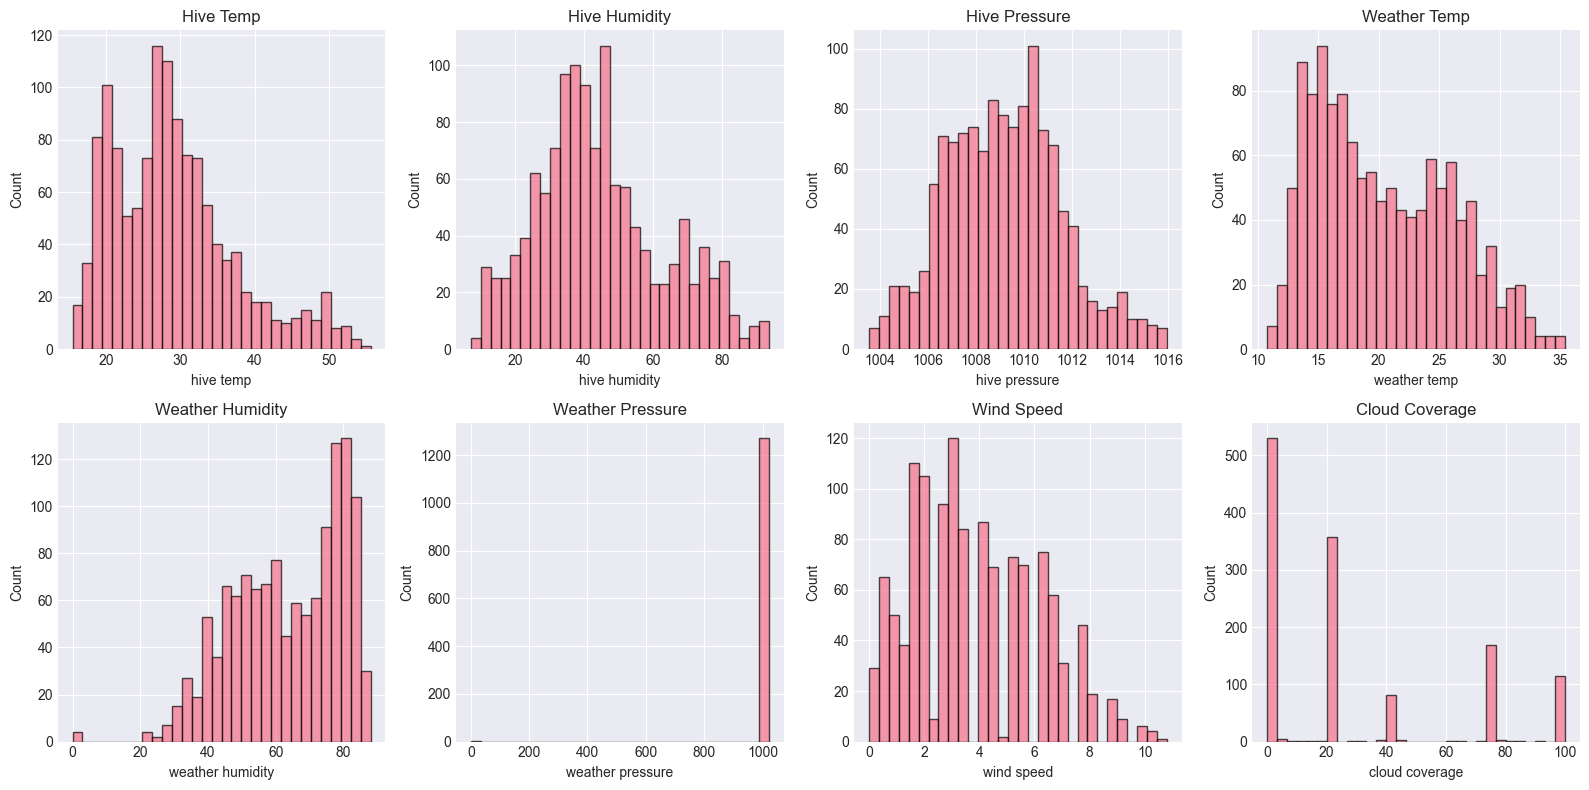

In [14]:
# Analyze environmental variables
env_cols = ['hive temp', 'hive humidity', 'hive pressure', 
            'weather temp', 'weather humidity', 'weather pressure',
            'wind speed', 'cloud coverage']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(env_cols):
    ax = axes[i]
    df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(col.title())
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'environmental_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


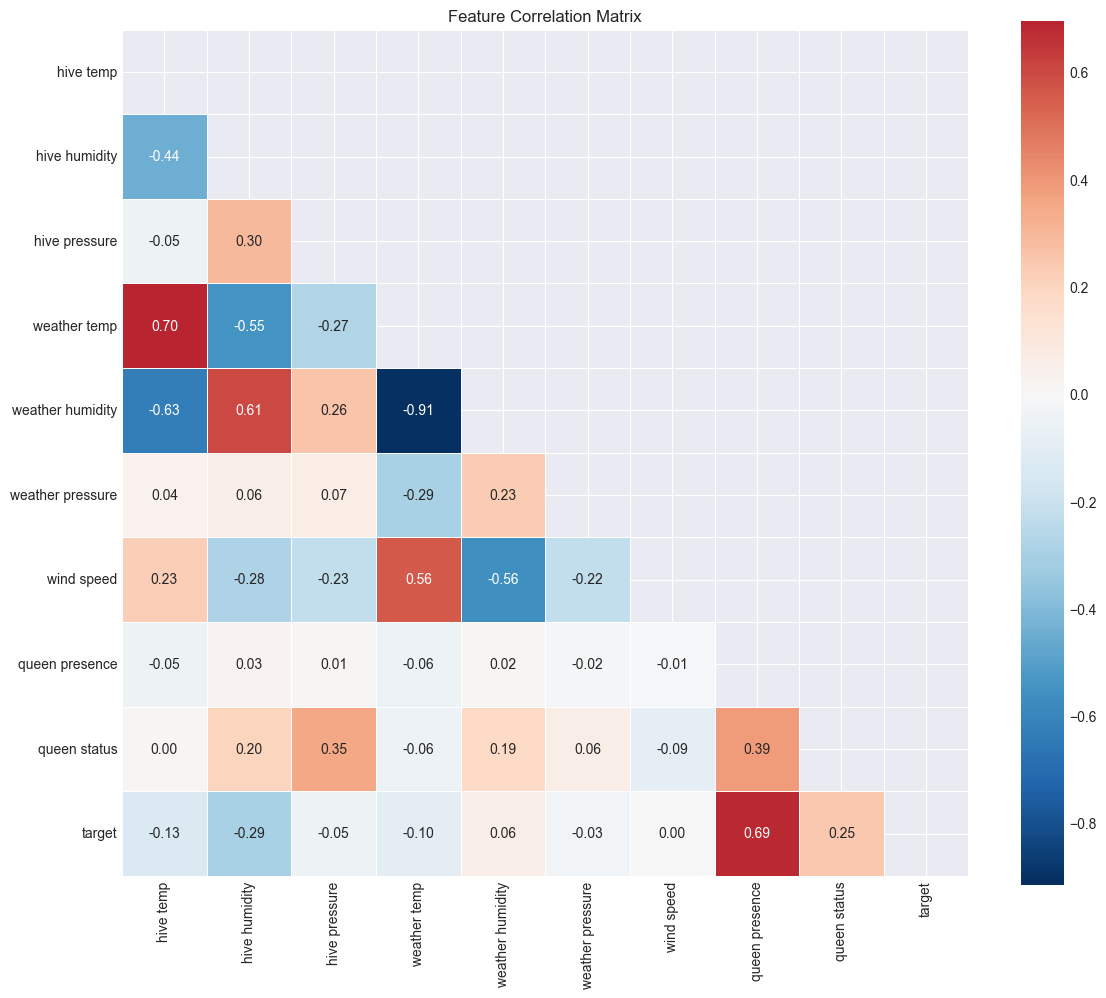

In [15]:
# Correlation matrix
numeric_cols = ['hive temp', 'hive humidity', 'hive pressure', 
                'weather temp', 'weather humidity', 'weather pressure',
                'wind speed', 'queen presence', 'queen status', 'target']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Spectrogram Visualization by Class


In [16]:
def find_audio_files_for_csv_row(row, audio_dir):
    """Find all segment WAV files corresponding to a CSV row."""
    # CSV has filename like: 2022-06-08--14-52-28_1.raw
    # WAV files are: 2022-06-08--14-52-28_1__segment0.wav, etc.
    base_name = row['file name'].replace('.raw', '')
    pattern = f"{base_name}__segment*.wav"
    matches = list(audio_dir.glob(pattern))
    return sorted(matches)

# Test the function
test_row = df.iloc[0]
test_files = find_audio_files_for_csv_row(test_row, AUDIO_DIR)
print(f"Test row filename: {test_row['file name']}")
print(f"Found {len(test_files)} audio files:")
for f in test_files:
    print(f"  {f.name}")


Test row filename: 2022-06-08--14-52-28_1.raw
Found 6 audio files:
  2022-06-08--14-52-28_1__segment0.wav
  2022-06-08--14-52-28_1__segment1.wav
  2022-06-08--14-52-28_1__segment2.wav
  2022-06-08--14-52-28_1__segment3.wav
  2022-06-08--14-52-28_1__segment4.wav
  2022-06-08--14-52-28_1__segment5.wav


In [17]:
# Filter to rows that have matching audio files
df['has_audio'] = df.apply(lambda row: len(find_audio_files_for_csv_row(row, AUDIO_DIR)) > 0, axis=1)
df_with_audio = df[df['has_audio']]
print(f"Rows with matching audio: {len(df_with_audio)} / {len(df)}")


Rows with matching audio: 1222 / 1275


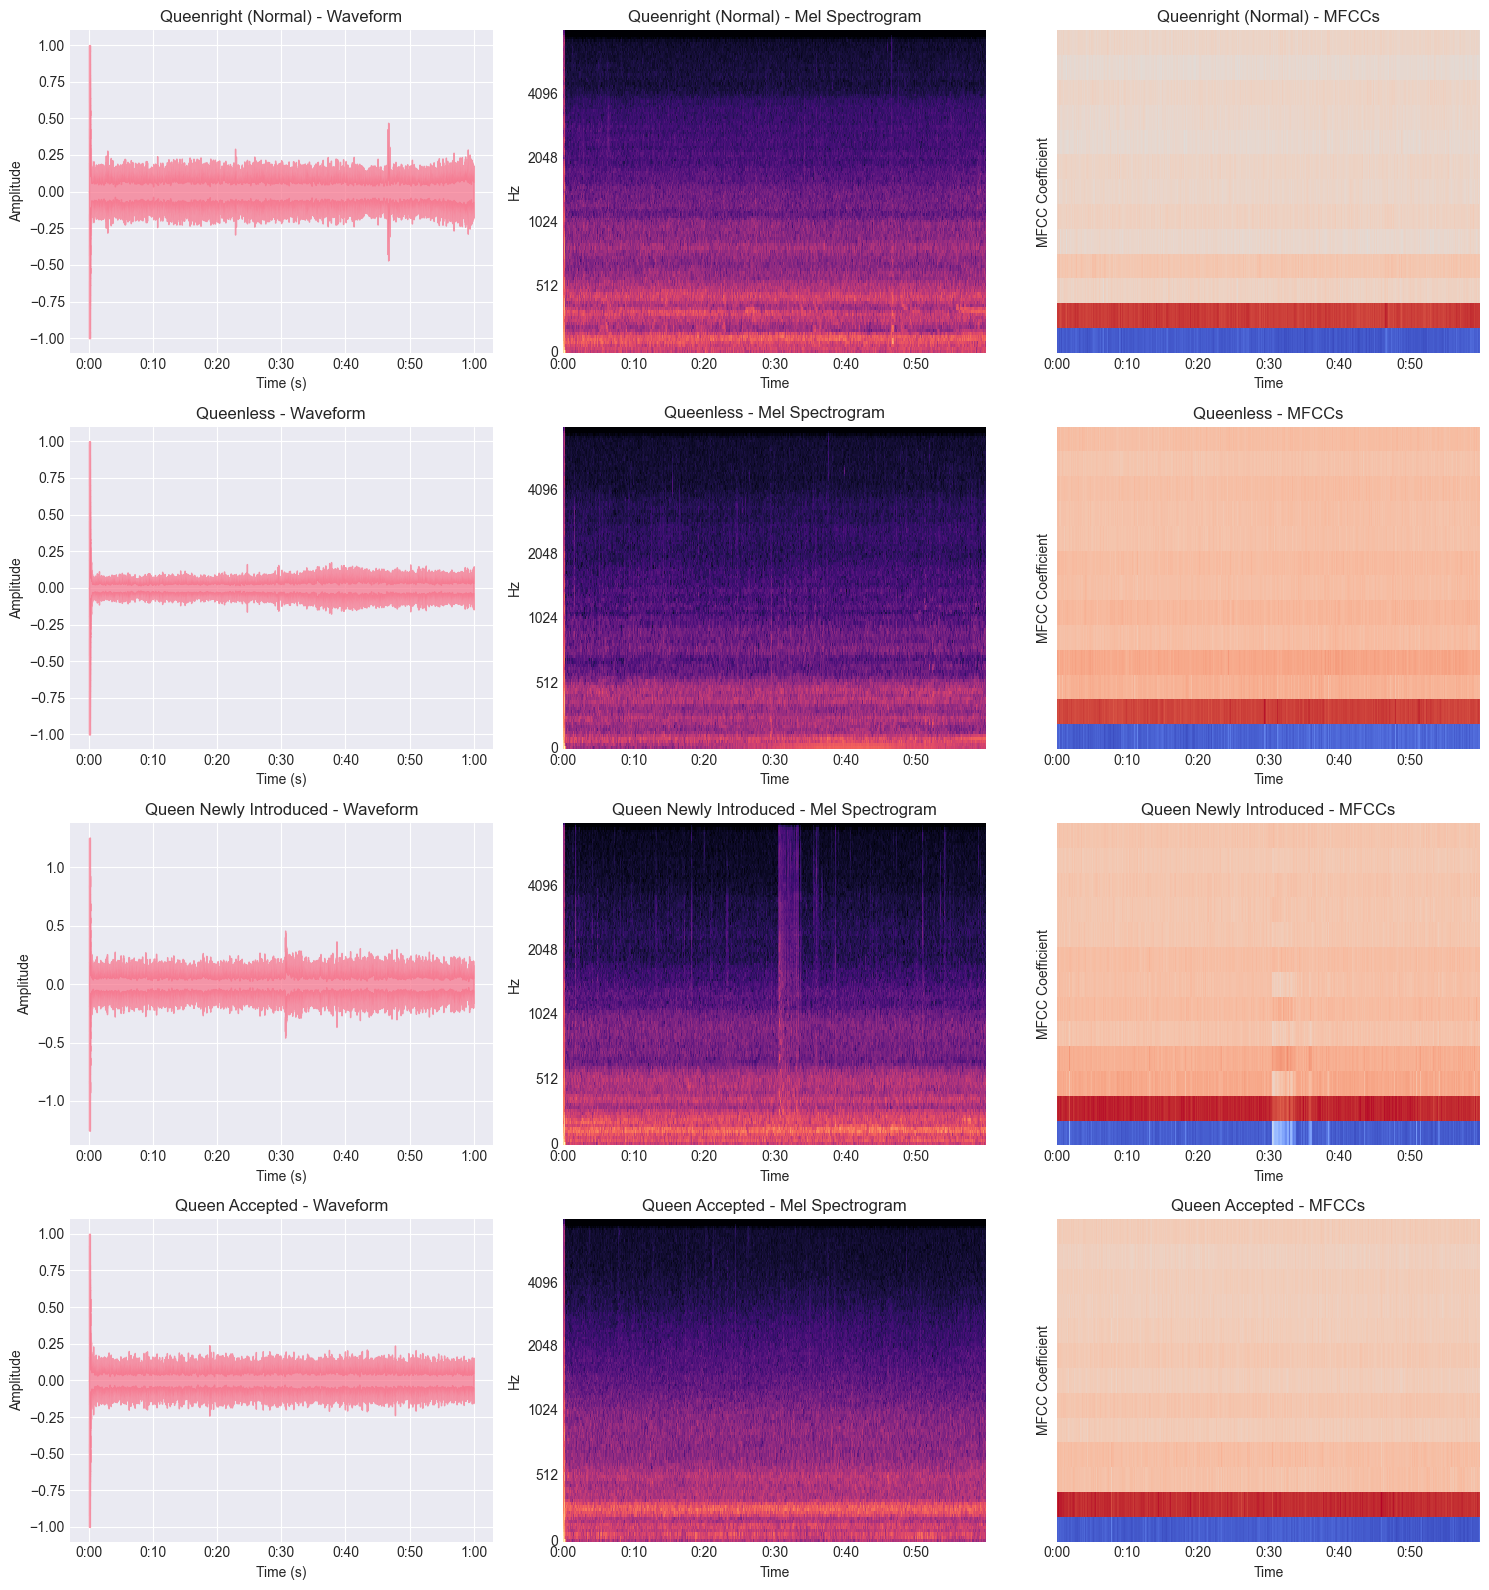

In [18]:
def plot_audio_features_comparison(df, audio_dir, class_mapping):
    """Compare audio features (waveform, spectrogram, MFCCs) for each class."""
    classes = sorted(df['queen status'].unique())
    
    fig, axes = plt.subplots(len(classes), 3, figsize=(15, 4*len(classes)))
    
    for i, status in enumerate(classes):
        class_df = df[df['queen status'] == status]
        sample_row = class_df.sample(1).iloc[0]
        audio_files = find_audio_files_for_csv_row(sample_row, audio_dir)
        
        if not audio_files:
            continue
        
        # Load audio
        y, sr = librosa.load(audio_files[0], sr=22050)
        
        class_name = class_mapping.get(status, str(status))
        
        # Waveform
        ax1 = axes[i, 0]
        librosa.display.waveshow(y, sr=sr, ax=ax1, alpha=0.7)
        ax1.set_title(f'{class_name} - Waveform')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Amplitude')
        
        # Mel Spectrogram
        ax2 = axes[i, 1]
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        S_dB = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=ax2)
        ax2.set_title(f'{class_name} - Mel Spectrogram')
        
        # MFCCs
        ax3 = axes[i, 2]
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        librosa.display.specshow(mfccs, x_axis='time', ax=ax3)
        ax3.set_title(f'{class_name} - MFCCs')
        ax3.set_ylabel('MFCC Coefficient')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'audio_features_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_audio_features_comparison(df_with_audio, AUDIO_DIR, CLASS_MAPPING)


## 6. Temporal Analysis


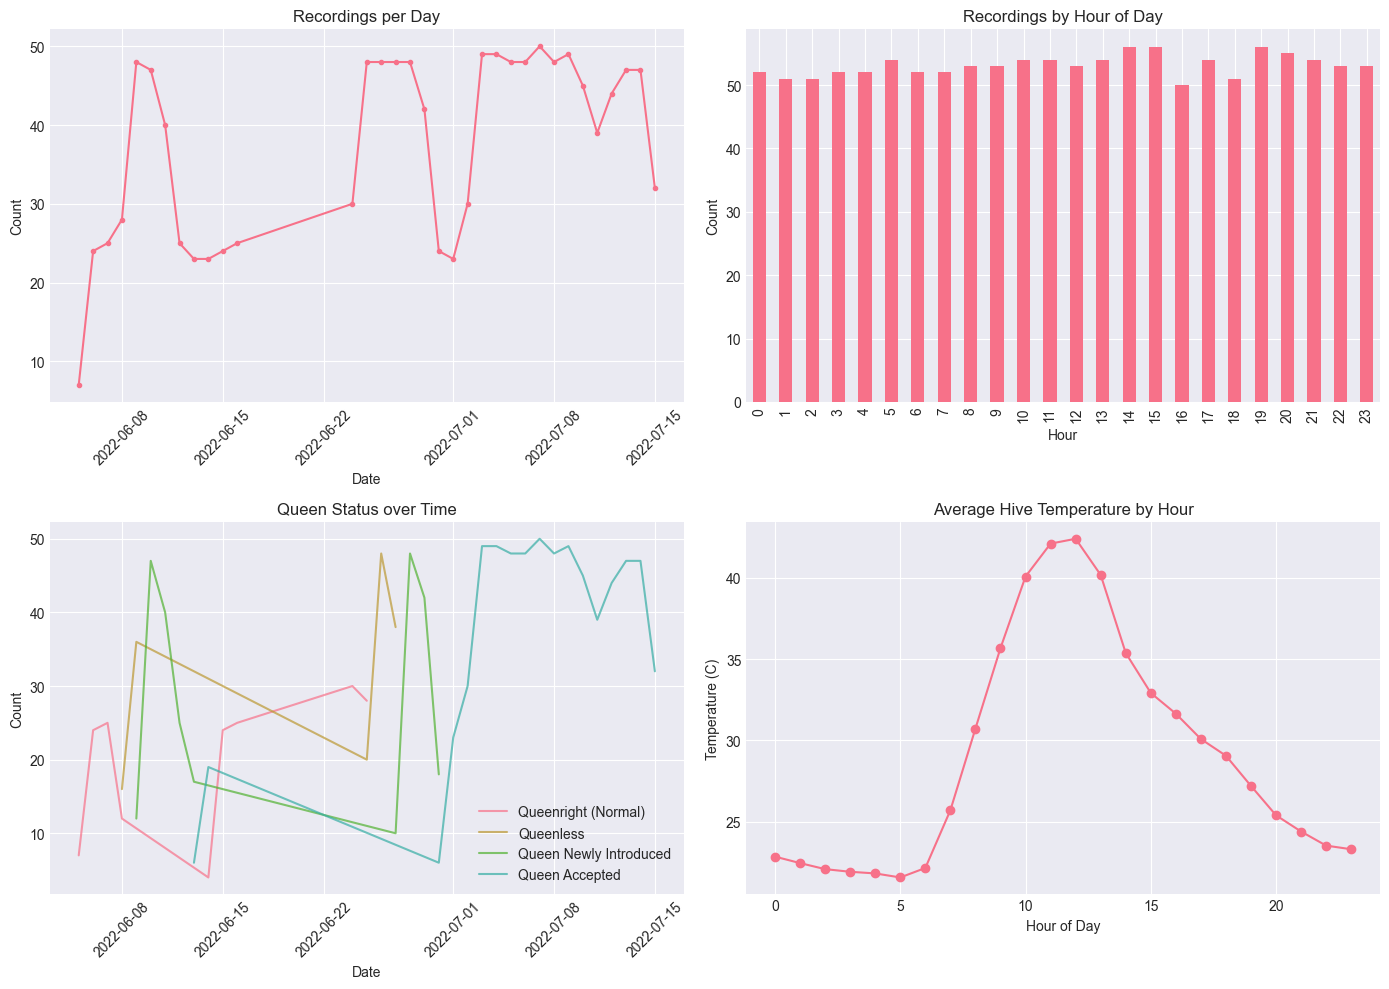

In [19]:
# Parse datetime
df['datetime'] = pd.to_datetime(df['date'])
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['date_only'] = df['datetime'].dt.date

# Recordings over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recordings per day
ax1 = axes[0, 0]
df.groupby('date_only').size().plot(ax=ax1, kind='line', marker='o', markersize=3)
ax1.set_title('Recordings per Day')
ax1.set_xlabel('Date')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Recordings by hour
ax2 = axes[0, 1]
df.groupby('hour').size().plot(ax=ax2, kind='bar')
ax2.set_title('Recordings by Hour of Day')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Count')

# Queen status over time
ax3 = axes[1, 0]
for status in sorted(df['queen status'].unique()):
    subset = df[df['queen status'] == status]
    daily_counts = subset.groupby('date_only').size()
    daily_counts.plot(ax=ax3, label=CLASS_MAPPING.get(status, str(status)), alpha=0.7)
ax3.set_title('Queen Status over Time')
ax3.set_xlabel('Date')
ax3.set_ylabel('Count')
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

# Hive temperature by hour
ax4 = axes[1, 1]
df.groupby('hour')['hive temp'].mean().plot(ax=ax4, kind='line', marker='o')
ax4.set_title('Average Hive Temperature by Hour')
ax4.set_xlabel('Hour of Day')
ax4.set_ylabel('Temperature (C)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Device and Hive Analysis


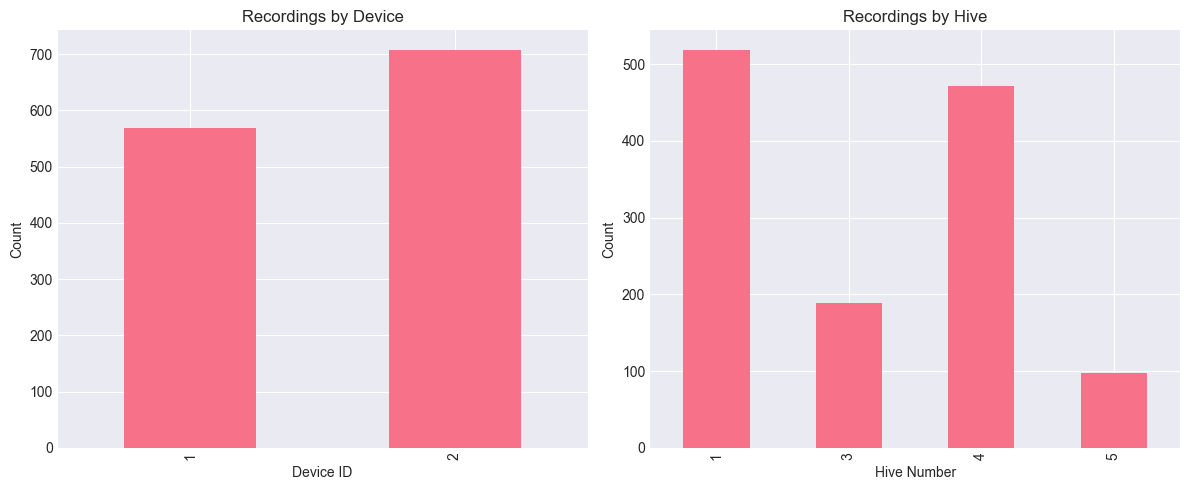


Unique devices: 2
Unique hives: 4


In [20]:
# Recordings by device and hive
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By device
ax1 = axes[0]
df['device'].value_counts().sort_index().plot(ax=ax1, kind='bar')
ax1.set_title('Recordings by Device')
ax1.set_xlabel('Device ID')
ax1.set_ylabel('Count')

# By hive
ax2 = axes[1]
df['hive number'].value_counts().sort_index().plot(ax=ax2, kind='bar')
ax2.set_title('Recordings by Hive')
ax2.set_xlabel('Hive Number')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'device_hive_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nUnique devices: {df['device'].nunique()}")
print(f"Unique hives: {df['hive number'].nunique()}")


## 8. Summary and Recommendations


In [21]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"\nDataset Statistics:")
print(f"   - Total metadata records: {len(df)}")
print(f"   - Total audio files (segments): {len(audio_files)}")
print(f"   - Records with matching audio: {len(df_with_audio)}")
print(f"   - Unique devices: {df['device'].nunique()}")
print(f"   - Unique hives: {df['hive number'].nunique()}")

print(f"\nLabel Distribution:")
for status, name in CLASS_MAPPING.items():
    count = (df['queen status'] == status).sum()
    pct = count / len(df) * 100
    print(f"   - {name}: {count} ({pct:.1f}%)")

print(f"\nAudio Properties:")
print(f"   - Sample rate: {set(sample_rates)}")
print(f"   - Segment duration: ~{np.mean(durations):.1f}s")
print(f"   - Segments per recording: 6")

print(f"\nData Quality Notes:")
missing_audio_count = len(df) - len(df_with_audio)
if missing_audio_count > 0:
    print(f"   - {missing_audio_count} records missing audio files")
print(f"   - Some environmental data has missing values")

print(f"\nRecommendations for Modeling:")
print(f"   1. Use queen_status as primary target (4 classes)")
print(f"   2. Consider class balancing (Queenright is most common)")
print(f"   3. Split by hive to prevent data leakage")
print(f"   4. Use 22050 Hz sample rate for consistency")
print(f"   5. Aggregate segments or use as separate samples")


DATASET SUMMARY

Dataset Statistics:
   - Total metadata records: 1275
   - Total audio files (segments): 7100
   - Records with matching audio: 1222
   - Unique devices: 2
   - Unique hives: 4

Label Distribution:
   - Queenright (Normal): 179 (14.0%)
   - Queenless: 158 (12.4%)
   - Queen Newly Introduced: 259 (20.3%)
   - Queen Accepted: 679 (53.3%)

Audio Properties:
   - Sample rate: {22050}
   - Segment duration: ~60.0s
   - Segments per recording: 6

Data Quality Notes:
   - 53 records missing audio files
   - Some environmental data has missing values

Recommendations for Modeling:
   1. Use queen_status as primary target (4 classes)
   2. Consider class balancing (Queenright is most common)
   3. Split by hive to prevent data leakage
   4. Use 22050 Hz sample rate for consistency
   5. Aggregate segments or use as separate samples


In [22]:
# Save processed dataframe for next notebook
df_with_audio.to_csv(OUTPUT_DIR / 'processed_metadata.csv', index=False)
print(f"Saved processed metadata to {OUTPUT_DIR / 'processed_metadata.csv'}")


Saved processed metadata to ../outputs/processed_metadata.csv
